# PointNet for RadHAR
Adapted to the raw GitHub dataset format with per-point features `[x, y, z, range, velocity, doppler_bin, bearing, intensity]` and activity labels from the class folders.

we write the dimensions as such:
- T the amounf of time frames (30 frames per second)
- D the amount of features (8 features: x, y, z, range, velocity, doppler_bin, bearing and intensity)
- N the amounf of point per frame (set to 32)
- B the amounf of batches

Amongts the N dimension, theres invariance by permutation because poibt order doesn tmatter. To agcieve this token permuation invariance, the Max Pooling is added. However across the time dimension, the posiiton is important. To take into account that order, we introduce attention along the time dimenions.

In [1]:
from functools import lru_cache
from pathlib import Path
import time

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from IPython.display import clear_output
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Dataset

In [2]:
PROJECT_ROOT = Path('/Users/elo/Coding/radar_ml')
DATA_ROOT = PROJECT_ROOT / 'data' / 'RadHAR'
TRAIN_SPLIT_ROOT = DATA_ROOT / 'Train'
TEST_SPLIT_ROOT = DATA_ROOT / 'Test'

ACTIVITY_CLASS_NAMES = ('boxing', 'jack', 'jump', 'squats', 'walk')
ACTIVITY_INDEX = {name: idx for idx, name in enumerate(ACTIVITY_CLASS_NAMES)}

DEVICE = "mps"
CONFIG = {
    'feature_names': ('x', 'y', 'z', 'range', 'velocity', 'doppler_bin', 'bearing', 'intensity'),
    'feature_amount': 8,
    'frame_count': 60,   # amount of frames per window (time dimension)
    'stride_frame_count': 60,  # time offset between two windows
    'points_per_frame': 32,   # constant amount of points per frame for tensor shapes
    'validation_fraction': 0.2,
    'normalized_feature_clip': 4.0, # outliers explode the validation losses, which prevents from evaluating the model
    'head_amount': 8,
    'batch_size': 16,
    "num_epochs": 10,
    "base_lr": 1e-3,
    "adam_momentum": 0.9,  # from the PointNet paper
    "lr_decay_step": 20,
    "lr_decay_gamma": 0.5,
    "accum_iter": 1,
}

# Data

In [3]:
@lru_cache(maxsize=None)
def load_radhar_file_raw(file_path):
    "Helper to load a file and return the list of raw frames from it."
    tracked_keys = {'point_id', *CONFIG['feature_names']}
    points = []
    current_point = {}

    with Path(file_path).open('r') as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if not line:
                continue
            if line == '---':
                points.append(current_point)
                current_point = {}
                continue
            if ':' not in line:
                continue

            key, raw_value = line.split(':', 1)
            key = key.strip()
            if key in tracked_keys:
                current_point[key] = float(raw_value)

    if current_point:
        points.append(current_point)

    frames = []
    current_frame_points = []
    for point in points:
        point_id = int(point.get('point_id', -1))
        if point_id == 0 and current_frame_points:
            frames.append(torch.tensor(current_frame_points, dtype=torch.float32))
            current_frame_points = []

        feature_vector = [float(point.get(name, 0.0)) for name in CONFIG['feature_names']]
        current_frame_points.append(feature_vector)

    if current_frame_points:
        frames.append(torch.tensor(current_frame_points, dtype=torch.float32))

    return frames

In [4]:
@lru_cache(maxsize=None)
def train_normalization_stats():
    "Compute normalization stats over the training split." 
    all_points = []
    for file_path in sorted(TRAIN_SPLIT_ROOT.rglob('*.txt')):
        frames = load_radhar_file_raw(str(file_path))
        all_points.append(torch.cat(frames, dim=0))
    all_points = torch.cat(all_points, dim=0)
    mean = all_points.mean(dim=0)
    std = all_points.std(dim=0).clamp_min(1e-6)
    return mean, std

In [5]:
@lru_cache(maxsize=None)
def load_radhar_file(file_path):
    "Helper to load a file and return normalized frames from it." 
    mean, std = train_normalization_stats()
    frames = load_radhar_file_raw(file_path)
    return [(frame - mean) / std for frame in frames]

In [6]:
sample_file = next((DATA_ROOT / "Train").rglob("*.txt"))
frames = load_radhar_file(str(sample_file))
print(len(frames))
print(frames[0].shape) # (points_per_frame, feature_amount)

601
torch.Size([21, 8])


In [7]:
def build_window_index(split_root):
    "Creates windows indexes of lenght frame_count each offset by a stride of stride_frame_count"
    samples = []

    for class_name in ACTIVITY_CLASS_NAMES:
        class_dir = split_root / class_name
        for file_path in sorted(class_dir.glob('*.txt')):
            frames = load_radhar_file(str(file_path))
            max_start = len(frames) - CONFIG['frame_count']
            for start_idx in range(0, max_start + 1, CONFIG['stride_frame_count']):
                samples.append((str(file_path), start_idx, ACTIVITY_INDEX[class_name]))
    return samples

In [8]:
@lru_cache(maxsize=None)
def split_train_val_file_paths():
    "Split the training files into train and validation sets at the file level." 
    train_files = []
    val_files = []
    for class_name in ACTIVITY_CLASS_NAMES:
        file_paths = sorted((TRAIN_SPLIT_ROOT / class_name).glob('*.txt'))
        val_count = max(1, int(len(file_paths) * CONFIG['validation_fraction']))
        val_count = min(val_count, len(file_paths) - 1)
        train_files.extend(str(path) for path in file_paths[:-val_count])
        val_files.extend(str(path) for path in file_paths[-val_count:])
    return train_files, val_files

In [9]:
def build_window_index_from_files(file_paths):
    "Create windows indexes from a list of files." 
    samples = []
    for file_path in file_paths:
        class_name = Path(file_path).parent.name
        frames = load_radhar_file(str(file_path))
        max_start = len(frames) - CONFIG['frame_count']
        for start_idx in range(0, max_start + 1, CONFIG['stride_frame_count']):
            samples.append((str(file_path), start_idx, ACTIVITY_INDEX[class_name]))
    return samples

In [10]:
train_windows = build_window_index(TRAIN_SPLIT_ROOT)
print(len(train_windows))
print(train_windows[:5])

2137
[('/Users/elo/Coding/radar_ml/data/RadHAR/Train/boxing/20_boxing_1.txt', 0, 0), ('/Users/elo/Coding/radar_ml/data/RadHAR/Train/boxing/20_boxing_1.txt', 60, 0), ('/Users/elo/Coding/radar_ml/data/RadHAR/Train/boxing/20_boxing_1.txt', 120, 0), ('/Users/elo/Coding/radar_ml/data/RadHAR/Train/boxing/20_boxing_1.txt', 180, 0), ('/Users/elo/Coding/radar_ml/data/RadHAR/Train/boxing/20_boxing_1.txt', 240, 0)]


In [11]:
def process_frame(points):
    "Keep the same point slots in order across a window, padding with zeros if needed."
    points = torch.as_tensor(points, dtype=torch.float32)
    points = points.clamp(-CONFIG['normalized_feature_clip'], CONFIG['normalized_feature_clip'])

    if len(points) >= CONFIG['points_per_frame']:
        return points[:CONFIG['points_per_frame']]

    padded = torch.zeros((CONFIG['points_per_frame'], CONFIG['feature_amount']), dtype=torch.float32)
    padded[:len(points)] = points
    return padded

In [12]:
processed_frame = process_frame(frames[0])
print(processed_frame.shape)

torch.Size([32, 8])


In [13]:
class RadHARDataset(Dataset):
    "Dataset, conatining the frames"
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, start_idx, label_idx = self.samples[idx]
        frames = load_radhar_file(file_path)
        window = frames[start_idx:start_idx + CONFIG['frame_count']]

        processed_frames = [process_frame(frame) for frame in window]
        sequence = torch.stack(processed_frames, dim=0)
        label = torch.tensor(label_idx, dtype=torch.long)
        return sequence, label

In [14]:
train_data = RadHARDataset(train_windows)
print(len(train_data))
x, y = train_data[0]
print(x.shape, y)

2137
torch.Size([60, 32, 8]) tensor(0)


# architecture

In [15]:
def xavier_init(module):
    "Helper to initialize weights with Xavier uniform, ignoring biaises and scalars."
    for p in module.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)

In [16]:
import copy
def clones(module, N):
    "Helper to produce N identical layers."
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])

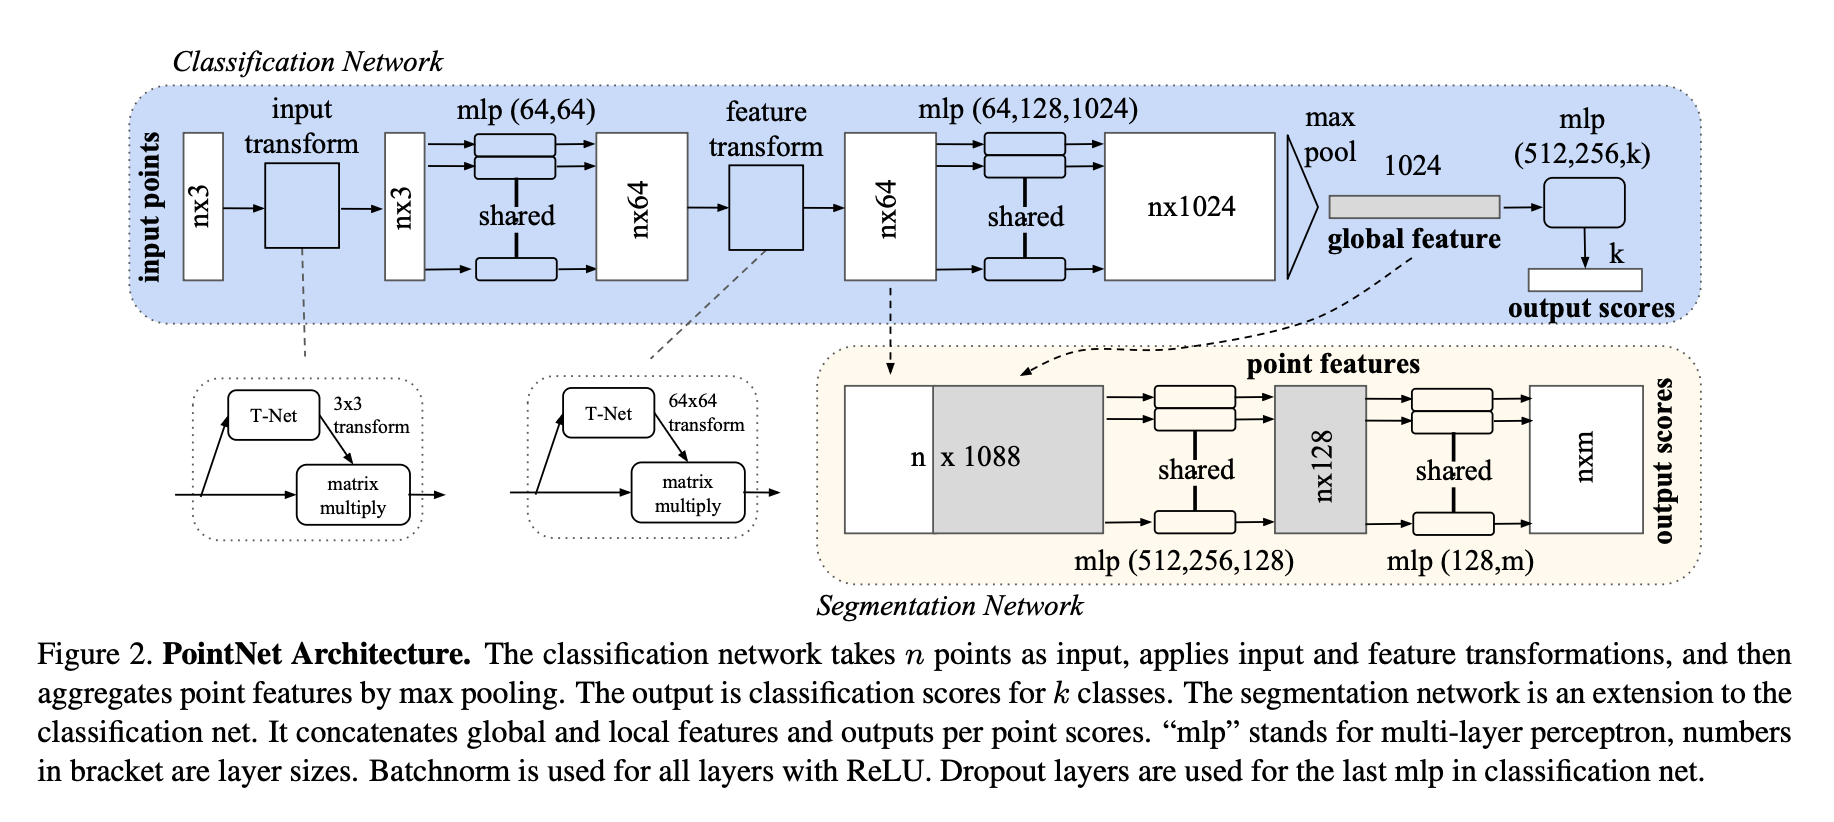

In [17]:
class TNet(nn.Module):
    """Layer inside the transform layers. Outputs a D*D matrix to multiply the input.``
    This is meant to rotate+scale the points to make it size/rotation invariant.
    Invertible matrix with the loss penalties.
    """
    def __init__(self, feature_count):
        super().__init__()
        self.feature_count = feature_count
        self.ff1 = nn.Linear(feature_count, 64)
        self.norm1 = PointBatchNorm(64)
        self.ff2 = nn.Linear(64, 128)
        self.norm2 = PointBatchNorm(128)
        self.ff3 = nn.Linear(128, 1024)
        self.norm3 = PointBatchNorm(1024)
        self.ff4 = nn.Linear(1024, 512)
        self.norm4 = PointBatchNorm(512)
        self.ff5 = nn.Linear(512, 256)
        self.norm5 = PointBatchNorm(256)
        self.ff6 = nn.Linear(256, feature_count * feature_count)
        xavier_init(self)
        nn.init.zeros_(self.ff6.weight)
        nn.init.zeros_(self.ff6.bias)

    def forward(self, x):
        # x : (B, T, N, D)
        batch_size, frame_count, _, _ = x.shape
        x = F.relu(self.norm1(self.ff1(x)))
        x = F.relu(self.norm2(self.ff2(x)))
        x = F.relu(self.norm3(self.ff3(x)))
        x = torch.max(x, dim=2)[0].unsqueeze(2) # max-reduction over N, keeps one point per feature
        x = F.relu(self.norm4(self.ff4(x)))
        x = F.relu(self.norm5(self.ff5(x)))
        x = self.ff6(x)  # last layer isn't normalized nor activated
        mat = x.view(batch_size, frame_count, self.feature_count, self.feature_count) # (B, T, D, D)
        eye = torch.eye(self.feature_count, device=x.device).unsqueeze(0).repeat(batch_size, frame_count, 1, 1)
        # T identity matrices, shape: (B, T, D, D)
        return mat + eye

In [18]:
class PointBatchNorm(nn.Module):
    "BatchNorm with one channel per feature; stats are over batch and points."
    def __init__(self, feature_count):
        super().__init__()
        self.norm = nn.BatchNorm1d(feature_count)

    def forward(self, x):
        if x.dim() == 2:
            return self.norm(x)

        batch_size, frame_count, point_count, feature_count = x.shape
        x = x.reshape(batch_size * frame_count * point_count, feature_count)
        x = self.norm(x)
        return x.view(batch_size, frame_count, point_count, feature_count)

In [19]:
def frequencies(feature_count, max_padding, theta = 1000):
    """Precompute the frequencies for all token positions in the sentence and
    for all pairs of features."""
    freqs = 1.0 / (theta ** (torch.arange(0, feature_count, 2) / feature_count))
    # the first feature pairs have high frequency, hence distance sensitive, the final pairs have low frequencies and are capture global properties
    t = torch.arange(max_padding)
    freqs = torch.outer(t, freqs).float() # all possible products
    return torch.cos(freqs), torch.sin(freqs)

def embed_positions(A, cos, sin):
    """Apply the rotation to q and k to embed token relative positions."""
    cos, sin = (x[:A.size(-2)].to(A)[None, None].repeat_interleave(2, dim=-1) for x in (cos, sin))
    x1, x2 = A.chunk(2, dim=-1)
    return A * cos + torch.cat((-x2, x1), dim=-1) * sin

In [20]:
def attention(query, key, value, dropout):
    "Scaled dot product between query and key, and distribute the scores on value."
    # q, k, v: (B, H, N, T, D/H)
    d_k = query.size(-1)  # reduced space head_dimension 
    scores = torch.matmul(query, key.transpose(-2, -1)) / (d_k ** 0.5) # scores : (B, H, N, T, T)
    # divide by sqrt(d_k) to not reach softmax plateau where gradient is almost zero

    p_attn = scores.softmax(dim=-1) # probability of key answering query
    p_attn = dropout(p_attn) 
    return torch.matmul(p_attn, value) # (B, H, N, T, D/H)

In [21]:
class MultiHeadedAttention(nn.Module):
    """
    Multi-head attention module: projects into smaller dimension spaces 
    and then apply specialized attention in each of them.
    Here a point is updated with with respect to the time dimension
    """

    def __init__(self, head_amount, feature_count, frame_count, dropout_rate):
        super().__init__()
        self.head_dimension = feature_count // head_amount # smaller head space dimension
        self.head_amount = head_amount
        self.linears = clones(nn.Linear(feature_count, feature_count, bias=False), 4) # Q, K, V, Out 
        self.dropout = nn.Dropout(dropout_rate)

        cos, sin = frequencies(self.head_dimension, frame_count)
        self.register_buffer("sin", sin) # to move them on DEVICE with the instance
        self.register_buffer("cos", cos)
        xavier_init(self)

    def forward(self, x):
        # x: (B, T, N, D)
        B, T, N, _ = x.size()

        query, key, value = [
            lin(x).view(B, T, N, self.head_amount, self.head_dimension).transpose(1, 3)
            for lin, x in zip(self.linears, (x, x, x)) 
        ] # q, k, v: (B, T, N, H, D/H) -> (B, H, N, T, D/H)

        query = embed_positions(query, self.cos, self.sin)
        key = embed_positions(key, self.cos, self.sin)
        x = attention(query, key, value, dropout=self.dropout) # (B, H, N, T, D/H)
        x = x.transpose(1, 3).reshape(B, T, N, self.head_amount * self.head_dimension) # (B, T, N, D)
        
        return self.linears[3](x) # apply final linear projection

In [22]:
class EncoderBlock(nn.Module):
    """Block of the main architecture contaning a TNet tranformed
    followed by a shared mlp, followed by an attention layer across time dimension."""

    def __init__(self, input_feature, mlp_dims):
        super().__init__()
        self.tnet = TNet(feature_count=input_feature)
        self.mlp_layers = nn.ModuleList()
        self.mlp_norms = nn.ModuleList()
        for in_dim, out_dim in zip(mlp_dims[:-1], mlp_dims[1:]):
            self.mlp_layers.append(nn.Linear(in_dim, out_dim))
            self.mlp_norms.append(PointBatchNorm(out_dim))
        #self.attention = MultiHeadedAttention(CONFIG["head_amount"], mlp_dims[-1], CONFIG['frame_count'], 0.1)
 
    def forward(self, x):
        # x: (B, T, N, D)
        self.trans_matrix = self.tnet(x) # (B, T, D, D)
        x = x @ self.trans_matrix # transform layer mutiplying the input by TNet matrix

        for linear, norm in zip(self.mlp_layers[:-1], self.mlp_norms[:-1]):
            x = F.relu(norm(linear(x)))
        x = self.mlp_norms[-1](self.mlp_layers[-1](x)) # last linear not followed by ReLU

        #attention = self.attention(x)
        return x


In [23]:
class Generator(nn.Module):
    "Compute logits from the global features."
    def __init__(self, class_amount = len(ACTIVITY_CLASS_NAMES), dropout_rate=0.3):
        super().__init__()
        self.ff1 = nn.Linear(1024, 512)
        self.norm1 = PointBatchNorm(512)
        self.ff2 = nn.Linear(512, 256)
        self.norm2 = PointBatchNorm(256)
        self.ff3 = nn.Linear(256, class_amount)
        self.dropout = nn.Dropout(dropout_rate)  # 0.3 is the value used in the paper
        xavier_init(self)
    
    def forward(self, x):
        # x: (B, T, 1024)
        x = F.relu(self.norm1(self.ff1(x)))
        x = F.relu(self.norm2(self.ff2(x)))
        x = self.dropout(x)

        return self.ff3(x)

In [24]:
class PointNet(nn.Module):
    "The whole architecture"
    def __init__(self, feature_amount):
        super().__init__()
        self.block1 = EncoderBlock(feature_amount, [feature_amount, 64, 64])
        self.block2 = EncoderBlock(64, [64, 64, 128, 1024])
        self.generator = Generator()

    def forward(self, x):
        # x: (B, T, N, D)
        batch_size, frame_count, _, _ = x.shape
        x = self.block1(x) # x: (B, T, N, 64)
        x = self.block2(x) # x: (B, T, N, 1024)
        x = torch.max(x, dim=2)[0]  # maxpool over N
        x = x.view(batch_size, frame_count, 1024).mean(dim=1)
        logits = self.generator(x)
        return logits

In [25]:
train_files, valid_files = split_train_val_file_paths()
train_samples = build_window_index_from_files(train_files)
valid_samples = build_window_index_from_files(valid_files)
test_samples = build_window_index(TEST_SPLIT_ROOT)
print(f'Train windows: {len(train_samples)}')
print(f'Validation windows: {len(valid_samples)}')
print(f'Test windows: {len(test_samples)}')

train_dataset = RadHARDataset(train_samples)
valid_dataset = RadHARDataset(valid_samples)
test_dataset = RadHARDataset(test_samples)
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=CONFIG['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

Train windows: 1878
Validation windows: 259
Test windows: 638


In [26]:
model = PointNet(CONFIG["feature_amount"])

sample_batch, sample_labels = next(iter(train_loader))
print(f'Input shape: {sample_batch.shape}')
print(f'Label shape: {sample_labels.shape}')

output = model(sample_batch)
print(f'Output shape: {output.shape}')

Input shape: torch.Size([16, 60, 32, 8])
Label shape: torch.Size([16])
Output shape: torch.Size([16, 5])


# training

In [27]:
def create_dataloaders(batch_size):
    "Create train and validation dataloaders."
    train_files, valid_files = split_train_val_file_paths()
    train_samples = build_window_index_from_files(train_files)
    valid_samples = build_window_index_from_files(valid_files)
    train_dataset = RadHARDataset(train_samples)
    valid_dataset = RadHARDataset(valid_samples)
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
    return train_dataloader, valid_dataloader

In [28]:
def rate(step, feature_amount, factor=1, warmup=200):
    "Learning rate schedule."
    step = max(step, 1)
    return factor * (feature_amount ** (-0.5) * min(step ** (-0.5), step * warmup ** (-1.5)))

In [29]:
def orthogonal(matrix):
    "Penalty term to make the TNet matrices more orthogonal."
    batch_size, frame_count, feature_count, _ = matrix.shape # matrix: (B, T, D, D)
    eye = torch.eye(feature_count, device=matrix.device).unsqueeze(0).repeat(batch_size, frame_count, 1, 1)
    diff = eye - matrix@matrix.transpose(-1,-2)
    return diff.pow(2).sum(dim=(-1, -2)).mean()

In [30]:
class SimpleLossCompute:
    "Loss compute helper matching run_epoch signature."
    def __init__(self, model, regul_coeff = 0.001):
        self.model = model
        self.regul_coeff = regul_coeff

    def __call__(self, out, targets, batch_size):
        loss_node = F.cross_entropy(out, targets) # negative log-likelihood loss
        reg1 = orthogonal(self.model.block1.trans_matrix)
        reg2 = orthogonal(self.model.block2.trans_matrix)
        loss_node = loss_node + self.regul_coeff * (reg1 + reg2)
        loss = loss_node.detach() * batch_size
        return loss, loss_node

In [31]:
def run_epoch(data_iter, model, loss_compute, optimizer=None, mode="train", accum_iter=1):
    "Runs one epoch, either for training, either validation."
    start = time.time()
    device = torch.device(DEVICE)
    total_tokens, total_loss, tokens, n_accum = 0, 0, 0, 0
    loss_list, grad_norms = [], []

    for i, batch in enumerate(data_iter):
        src, targets = batch
        src = src.to(device)
        targets = targets.to(device)
        ntokens = targets.size(0)

        out = model.forward(src)
        loss, loss_node = loss_compute(out, targets, ntokens)

        if mode == "train":
            (loss_node / accum_iter).backward()
            if i % accum_iter == 0:
                if optimizer is not None:
                    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), float("inf"))
                    grad_norms.append(norm.item())
                    optimizer.step()
                    optimizer.zero_grad(set_to_none=True)
                n_accum += 1

        total_loss += loss
        total_tokens += ntokens
        tokens += ntokens
        loss_list.append((loss / ntokens).item())

        if i % 40 == 1 and (mode == "train"):
            lr = optimizer.param_groups[0]["lr"]
            elapsed = time.time() - start
            print(
                ("Batch: %6d | Accum. Step: %3d | Loss: %6.2f " + "| Samples/sec: %7.1f | Learn. Rate: %6.1e")
                % (i, n_accum, loss / ntokens, tokens / elapsed, lr)
            )
            start = time.time()
            tokens = 0

    return loss_list, grad_norms

In [32]:
def plot(train_losses, valid_losses, all_grad_norms, model_param_count, num_epochs, train_epoch_sizes, valid_epoch_sizes, epoch_means):
    "Plot the losses and the gradient norm over the training process."
    x_train = []
    for epoch, epoch_size in enumerate(train_epoch_sizes):
        x_train.extend(epoch + i / epoch_size for i in range(epoch_size))

    x_valid = []
    epoch_mean_valid_losses = []
    for epoch, (epoch_size, mean_val) in enumerate(zip(valid_epoch_sizes, epoch_means)):
        x_valid.extend(epoch + i / epoch_size for i in range(epoch_size))
        epoch_mean_valid_losses.extend([mean_val] * epoch_size)

    x_grad = []
    for epoch, epoch_size in enumerate(train_epoch_sizes):
        x_grad.extend(epoch + i / epoch_size for i in range(epoch_size))

    plt.figure(figsize=(10, 10))
    
    ax1 = plt.subplot(2, 1, 1)
    train_batches_per_epoch = len(train_losses) / num_epochs
    window_size = max(1, int(train_batches_per_epoch * 0.1))
    train_loss_rolling = pd.Series(train_losses).rolling(window=window_size, center=True).mean()
    plt.plot(x_train, train_losses, label="Training Loss")
    plt.plot(x_train, train_loss_rolling, label="Training Loss (Avg)", color="darkblue", linewidth=1)
    plt.plot(x_valid, valid_losses, label="Validation Loss", alpha=0.7)
    plt.plot(x_valid, epoch_mean_valid_losses, label="Val Loss (Avg)", color="red", linewidth=1, linestyle="--")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Training and Validation Loss Over Epochs")
    ax1.set_xlim(0, num_epochs)
    ax1.set_xticks(range(num_epochs + 1))
    loss_values = pd.Series(train_losses + valid_losses + epoch_means).dropna()
    loss_q1 = loss_values.quantile(0.25)
    loss_q3 = loss_values.quantile(0.75)
    loss_iqr = loss_q3 - loss_q1
    loss_bottom = max(0, loss_q1 - 1.5 * loss_iqr)
    loss_top = loss_q3 + 1.5 * loss_iqr
    if loss_top < loss_values.max():
        loss_margin = max((loss_top - loss_bottom) * 0.05, 1e-6)
        ax1.set_ylim(loss_bottom, loss_top + loss_margin)
    y_min, y_max = ax1.get_ylim()
    best_mean_val = float("inf")
    for i, mean_val in enumerate(epoch_means):
        if mean_val <= best_mean_val and y_min <= mean_val <= y_max:
            ax1.text(i + 0.5, mean_val, f"{mean_val:.3g}",
                     color="red",
                     ha="center",
                     va="bottom",
                     fontweight="medium",
                     clip_on=True)
        best_mean_val = min(best_mean_val, mean_val)
        
    plt.subplot(2, 1, 2)
    plt.plot(x_grad, all_grad_norms, label="Gradient Norm", color="orange")
    plt.xlabel("Epochs")
    plt.ylabel("Norm")
    plt.legend()
    plt.title("Gradient Norm over Epochs")
    ax = plt.gca()
    ax.set_xlim(0, num_epochs)
    ax.set_xticks(range(num_epochs + 1))
    grad_values = pd.Series(all_grad_norms).dropna()
    grad_q1 = grad_values.quantile(0.25)
    grad_q3 = grad_values.quantile(0.75)
    grad_iqr = grad_q3 - grad_q1
    grad_bottom = max(0, grad_q1 - 1.5 * grad_iqr)
    grad_top = grad_q3 + 1.5 * grad_iqr
    if grad_top < grad_values.max():
        grad_margin = max((grad_top - grad_bottom) * 0.05, 1e-6)
        ax.set_ylim(grad_bottom, grad_top + grad_margin)
    ax.text(0.99, 0.02, f"Params count: {model_param_count:,}", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=9, color="dimgray")

    plt.subplots_adjust(hspace=0.35)
    plt.show()

In [33]:
def train_model(num_epochs=CONFIG["num_epochs"]):
    "Launch the training process of a model."
    print("Training process starting...", flush=True)
    model = PointNet(CONFIG["feature_amount"])
    device = torch.device(DEVICE)
    model.to(device)
    model_param_count = sum(p.numel() for p in model.parameters())

    train_dataloader, valid_dataloader = create_dataloaders(batch_size=CONFIG["batch_size"])
    optimizer = torch.optim.Adam(model.parameters(),lr=CONFIG["base_lr"], betas=(CONFIG["adam_momentum"], 0.999))
    lr_scheduler = StepLR(optimizer, step_size=CONFIG["lr_decay_step"], gamma=CONFIG["lr_decay_gamma"])

    train_losses, valid_losses, all_grad_norms = [], [], []
    train_epoch_sizes, valid_epoch_sizes, epoch_means = [], [], []
    loss_compute = SimpleLossCompute(model)
    checkpoint_dir = PROJECT_ROOT / "checkpoints" / "radHAR"
    checkpoint_dir.mkdir(exist_ok=True)

    for epoch in range(num_epochs):
        model.train()
        print(f"Epoch n°{epoch} Training ====", flush=True)
        loss_list, grad_norms = run_epoch(
            train_dataloader,
            model,
            loss_compute,
            optimizer,
            mode="train",
            accum_iter=CONFIG["accum_iter"],
        )
        lr_scheduler.step()
        train_losses.extend(loss_list)
        train_epoch_sizes.append(len(loss_list))
        all_grad_norms.extend(grad_norms)

        file_path = checkpoint_dir / f"checkpoint_{epoch:02d}.pt"
        torch.save(model.state_dict(), file_path)

        print(f"Epoch n°{epoch} Validation ====", flush=True)
        model.eval()
        with torch.no_grad():
            loss_list, _ = run_epoch(
                valid_dataloader,
                model,
                loss_compute,
                None,
                mode="eval",
            )
        valid_losses.extend(loss_list)
        valid_epoch_sizes.append(len(loss_list))

        mean_val = sum(loss_list) / len(loss_list)
        epoch_means.append(mean_val)
        clear_output(wait=True)
        print("Training process starting...", flush=True)
        print(f"Epoch n°{epoch} complete | Validation loss: {mean_val:.4f}", flush=True)
        plot(train_losses, valid_losses, all_grad_norms, model_param_count, num_epochs, train_epoch_sizes, valid_epoch_sizes, epoch_means)

    return model

Training process starting...
Epoch n°19 complete | Validation loss: 0.0681


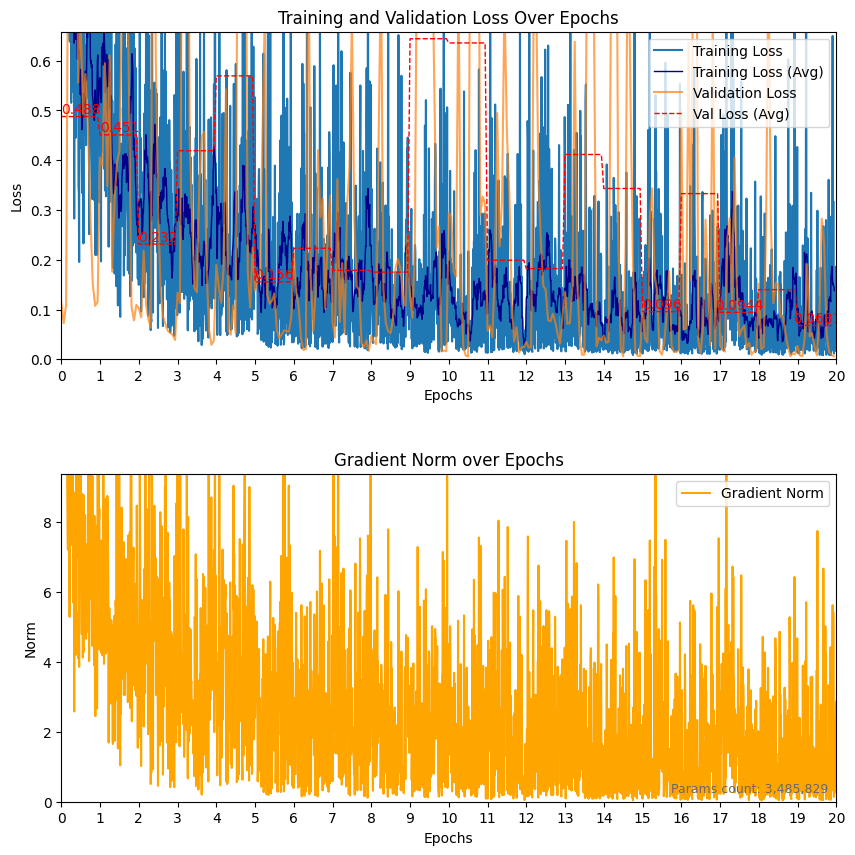

In [34]:
if __name__ == "__main__":
    train_model(20)

# inference

In [35]:
def compute_macro_f1(predictions, labels):
    scores = []
    for class_idx in range(len(ACTIVITY_CLASS_NAMES)):
        true_positive = ((predictions == class_idx) & (labels == class_idx)).sum().item()
        false_positive = ((predictions == class_idx) & (labels != class_idx)).sum().item()
        false_negative = ((predictions != class_idx) & (labels == class_idx)).sum().item()
        denominator = 2 * true_positive + false_positive + false_negative
        scores.append(0.0 if denominator == 0 else 2 * true_positive / denominator)
    return torch.tensor(scores, dtype=torch.float32)

In [36]:
def compute_accuracy(predictions, labels):
    return (predictions == labels).float().mean().item()

In [37]:
def evaluate_checkpoint(checkpoint_path):
    device = torch.device(DEVICE)
    model = PointNet(CONFIG['feature_amount']).to(device)
    state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()

    eval_samples = build_window_index(TEST_SPLIT_ROOT)
    eval_dataset = RadHARDataset(eval_samples)
    eval_loader = DataLoader(eval_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

    all_predictions = []
    all_labels = []
    with torch.no_grad():
        for batch, labels in eval_loader:
            logits = model(batch.to(device))
            all_predictions.append(logits.argmax(dim=1).cpu())
            all_labels.append(labels.cpu())

    predictions = torch.cat(all_predictions)
    labels = torch.cat(all_labels)
    per_class_f1 = compute_macro_f1(predictions, labels)
    macro_f1 = per_class_f1.mean().item()
    accuracy = compute_accuracy(predictions, labels)
    return macro_f1, {name: float(score) for name, score in zip(ACTIVITY_CLASS_NAMES, per_class_f1)}, accuracy

In [40]:
checkpoint_path = PROJECT_ROOT / "checkpoints/radHAR/checkpoint_10.pt"
macro_f1, per_class_f1, accuracy = evaluate_checkpoint(checkpoint_path)
print(f'Macro F1: {macro_f1:.4f}')
print(f'Accuracy: {accuracy:.4f}')
print(per_class_f1)

Macro F1: 0.9225
Accuracy: 0.9201
{'boxing': 0.9721115827560425, 'jack': 0.945147693157196, 'jump': 0.8533333539962769, 'squats': 0.9090909361839294, 'walk': 0.9328358173370361}


In [43]:
checkpoint_path = PROJECT_ROOT / "checkpoints/radHAR/checkpoint_06.pt"
macro_f1, per_class_f1, accuracy = evaluate_checkpoint(checkpoint_path)
print(f'Macro F1: {macro_f1:.4f}')
print(f'Accuracy: {accuracy:.4f}')
print(per_class_f1)

Macro F1: 0.8610
Accuracy: 0.8605
{'boxing': 0.9802371263504028, 'jack': 0.7777777910232544, 'jump': 0.7123287916183472, 'squats': 0.9535865187644958, 'walk': 0.8812260627746582}


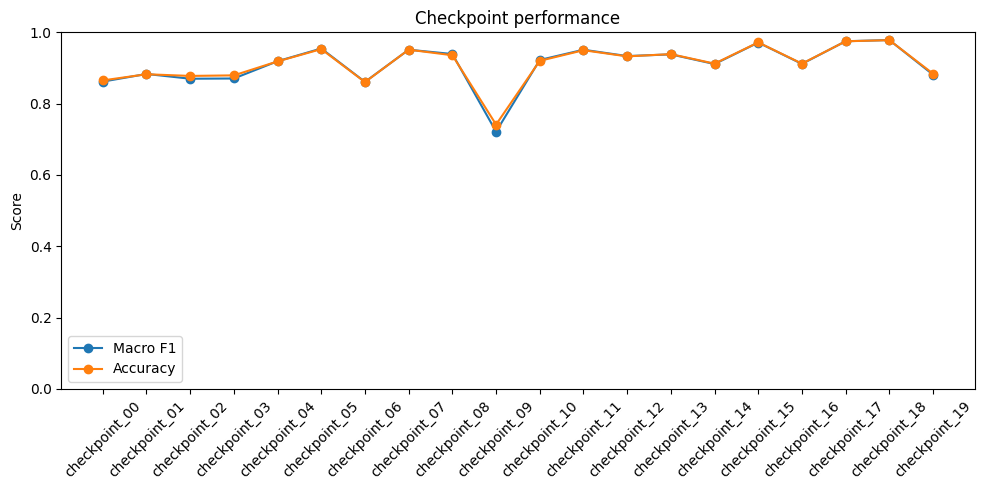

In [44]:
checkpoint_paths = sorted((PROJECT_ROOT / "checkpoints/radHAR").glob("checkpoint_*.pt"), key=lambda path: int(path.stem.split("_")[-1]))
metrics = [evaluate_checkpoint(path) for path in checkpoint_paths]
checkpoint_labels = [path.stem for path in checkpoint_paths]
macro_f1_scores = [metric[0] for metric in metrics]
accuracy_scores = [metric[2] for metric in metrics]

plt.figure(figsize=(10, 5))
plt.plot(checkpoint_labels, macro_f1_scores, marker="o", label="Macro F1")
plt.plot(checkpoint_labels, accuracy_scores, marker="o", label="Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.ylabel("Score")
plt.title("Checkpoint performance")
plt.legend()
plt.tight_layout()
plt.show()